In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import sys
import pickle as pkl
import pyvisa as visa
import datetime
from scipy.optimize import curve_fit
from collections import defaultdict
from scipy.stats import kurtosis, skew
import pandas as pd
from collections import OrderedDict
from pathlib import Path
import fnmatch
import time
from edes.modules.detection.detection_utils import plot, plot_ax, big_plt_font
from edes.experiments.devices.base import Agilent34461A, RigolDP832A, SiglentSPD3303X_E, SSA3032X_R
from edes.experiments import Experiment
from edes.utils.file_handling import load_exp_config
big_plt_font()

In [2]:
PSU = SiglentSPD3303X_E('TCPIP::192.168.169.101::INSTR')
SSA = SSA3032X_R('TCPIP::192.168.169.161::INSTR')

>>> Connected to Siglent Technologies,SPD3303X-E,SPD3XJEQ6R3773,1.01.01.02.07R2,V3.0

>>> Connected to Siglent Technologies,SSA3032X-R,SSA5PA1Q800415,3.2.2.6.0R10



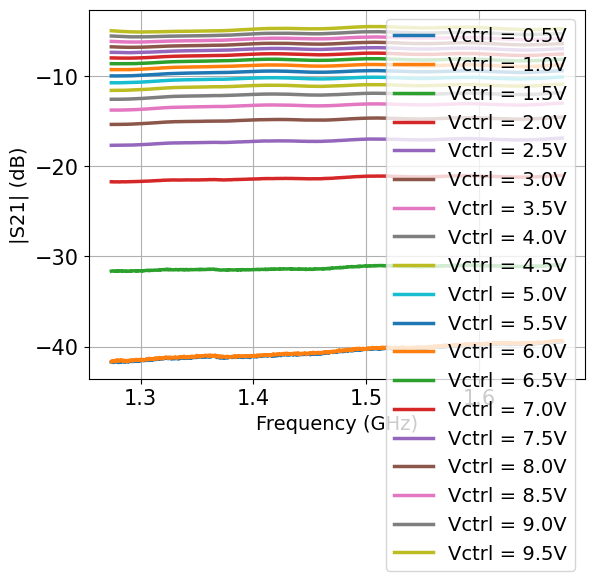

In [13]:
all_V = np.arange(0.5, 10, 0.5) 
all_S21 = []
for V in all_V:
    PSU.set_voltage(2, V)
    SSA.set_freq_center(1.474e9)
    SSA.set_freq_span(400e6)
    SSA.set_N_avg(1)
    time.sleep(3)
    SSA.auto_scale()
    freq, data = SSA.measure_VNA_spectrum(1) 
    plot(freq/1e9, data, xlabel='Frequency (GHz)', ylabel='|S21| (dB)', label=f'Vctrl = {V:.1f}V')#, title='VD = 1.4V')#, label=f'S11, VGS = {vgs:.2f} V')
    all_S21.append(data[np.argmin(abs(freq-1.474e9))])
plt.show()

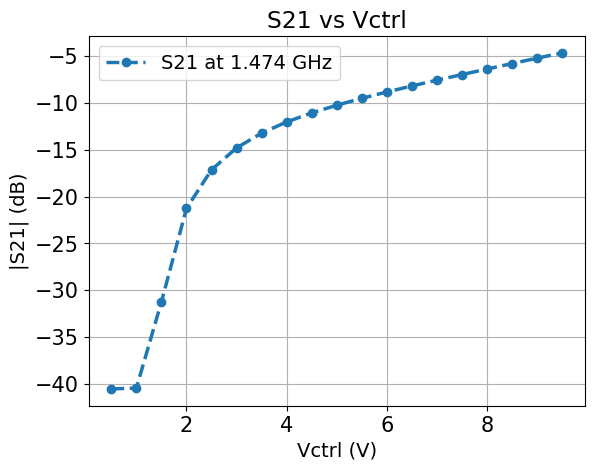

In [15]:
plot(all_V, all_S21, '.--', xlabel='Vctrl (V)', ylabel='|S21| (dB)', title='S21 vs Vctrl', label='S21 at 1.474 GHz')
plt.legend()
plt.show()

In [3]:
import numpy as np

def get_vctrl(p_out_desired_dbm):
    """
    Translates a desired output power to the required control voltage.
    Assumes a constant input power of 5 dBm.
    """
    P_IN = 5.0 # dBm
    
    # Required S21 to achieve the desired output power
    s21_required = p_out_desired_dbm - P_IN
    
    # Data extracted from the S21 vs Vctrl plot
    # Arrays must be monotonically increasing for numpy.interp to work properly on the x-axis
    s21_data = np.array([-40.5, -31.0, -21.0, -17.0, -15.0, -13.2, -12.0, -11.0, 
                         -10.0, -9.5, -8.8, -8.2, -7.6, -7.0, -6.4, -5.8, -5.2, -4.8])
    
    vctrl_data = np.array([1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 
                           5.0, 5.5, 6.0, 6.5, 7.0, 7.5, 8.0, 8.5, 9.0, 9.5])
    
    # Check if the requested power is physically possible with this attenuator
    if s21_required < s21_data[0]:
        raise ValueError(f"Desired P_out is too low. Minimum achievable S21 is {s21_data[0]} dB.")
    if s21_required > s21_data[-1]:
        raise ValueError(f"Desired P_out is too high. Maximum achievable S21 is {s21_data[-1]} dB.")
        
    # Interpolate to find the exact Vctrl
    vctrl_target = np.interp(s21_required, s21_data, vctrl_data)
    
    return vctrl_target

# Example Usage:
# If you want an output power of -10 dBm:
# S21 needed = -10 - 5 = -15 dB. Looking at the graph, this should be exactly 3.0V.
target_power = -10.0
print(f"Required Vctrl for {target_power} dBm: {get_vctrl(target_power):.2f} V")
target_power = 0.0
print(f"Required Vctrl for {target_power} dBm: {get_vctrl(target_power):.2f} V")

Required Vctrl for -10.0 dBm: 3.00 V
Required Vctrl for 0.0 dBm: 9.25 V
